# AI-Powered Telecom Customer Retention Platform

**Student:** Maurizio Pinto  
**Program:** Master's Degree in AI — Udacity / Woolf University  
**Date:** May 2026  

## Project Overview

This project integrates methods from three prior capstone projects into an end-to-end telecom customer retention system:

| Component | Prior Project | Methods |
|---|---|---|
| Statistical Analysis | Project 2 — Statistical Analysis | Chi-squared test, Welch's t-test, descriptive statistics |
| ML Churn Prediction | Project 3 — ML Model Design | Logistic Regression, Random Forest, feature importance |
| Agentic Retention Advisor | Project 6 — Agentic AI | ReAct loop, OpenAI function calling, safeguards |

**Pipeline flow:** Statistical Analysis → ML Prediction → Risk-Adjusted CLV → Agentic Retention Action

## Setup

In [1]:
import json
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from openai import OpenAI
from dotenv import load_dotenv

sns.set_theme(style='whitegrid')
%matplotlib inline
np.random.seed(42)

## Data Loading & Inspection

In [2]:
df = pd.read_csv('dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.shape[1]}, Rows: {df.shape[0]}')
df.head()

Dataset shape: (7043, 21)
Columns: 21, Rows: 7043


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing: 0


In [5]:
# Class distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print('Churn distribution:')
print(f'  No Churn:  {churn_counts["No"]:,} ({churn_pct["No"]:.1f}%)')
print(f'  Churn:     {churn_counts["Yes"]:,} ({churn_pct["Yes"]:.1f}%)')
print(f'  Churn rate: {churn_pct["Yes"]:.1f}%')

Churn distribution:
  No Churn:  5,174 (73.5%)
  Churn:     1,869 (26.5%)
  Churn rate: 26.5%


## Statistical Analysis — Validating Churn Patterns

This component applies methods from **Project 2 (Statistical Analysis)** to validate that observed churn patterns are statistically significant. We use:

- **Chi-squared test of independence** to test whether contract type and churn are associated (appropriate because churn is binary and contract type is categorical with 3 levels)
- **Welch's t-test** to test whether MonthlyCharges differ significantly between churners and non-churners (same test pattern as Project 2, where we compared insurance charges between smokers and non-smokers)
- **Descriptive statistics** segmented by key customer attributes

These tests provide human-interpretable evidence that informs segment-level retention strategy — complementing the ML model's individual-level predictions.

In [6]:
# Chi-squared test: Contract type vs. Churn
contingency = pd.crosstab(df['Contract'], df['Churn'])
print('Contingency table (Contract type × Churn):')
print(contingency)
print()

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f'Chi-squared test of independence:')
print(f'  χ² statistic = {chi2:.2f}')
print(f'  p-value      = {p_value:.2e}')
print(f'  degrees of freedom = {dof}')
print()

alpha = 0.05
if p_value < alpha:
    print(f'Result: REJECT H₀ (p = {p_value:.2e} < {alpha})')
    print('There IS a statistically significant association between contract type and churn.')
    print()
    churn_by_contract = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    print('Churn rates by contract type:')
    for contract, rate in churn_by_contract.items():
        print(f'  {contract:20s}: {rate:.1f}%')
else:
    print(f'Result: FAIL TO REJECT H₀ (p = {p_value:.2e} >= {alpha})')

Contingency table (Contract type × Churn):
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Chi-squared test of independence:
  χ² statistic = 1184.60
  p-value      = 5.86e-258
  degrees of freedom = 2

Result: REJECT H₀ (p = 5.86e-258 < 0.05)
There IS a statistically significant association between contract type and churn.

Churn rates by contract type:
  Month-to-month      : 42.7%
  One year            : 11.3%
  Two year            : 2.8%


In [7]:
# Welch's t-test: MonthlyCharges by Churn group
charges_churn = df[df['Churn'] == 'Yes']['MonthlyCharges']
charges_no_churn = df[df['Churn'] == 'No']['MonthlyCharges']

print('MonthlyCharges by churn group:')
print(f'  Churners (n={len(charges_churn)}):    mean=${charges_churn.mean():.2f}, median=${charges_churn.median():.2f}, std=${charges_churn.std():.2f}')
print(f'  Non-churners (n={len(charges_no_churn)}): mean=${charges_no_churn.mean():.2f}, median=${charges_no_churn.median():.2f}, std=${charges_no_churn.std():.2f}')
print()

# Assumption checks
stat_s1, p_s1 = stats.shapiro(charges_churn.sample(min(500, len(charges_churn)), random_state=42))
stat_s2, p_s2 = stats.shapiro(charges_no_churn.sample(min(500, len(charges_no_churn)), random_state=42))
stat_lev, p_lev = stats.levene(charges_churn, charges_no_churn)

print('Assumption checks:')
print(f'  Shapiro-Wilk (churners):    W={stat_s1:.4f}, p={p_s1:.4e}')
print(f'  Shapiro-Wilk (non-churners): W={stat_s2:.4f}, p={p_s2:.4e}')
print(f'  Levene (equal variance):     F={stat_lev:.2f}, p={p_lev:.2e}')
print(f'  → Variances are {"unequal" if p_lev < 0.05 else "equal"} → Welch\'s t-test is appropriate')
print()

t_stat, p_value = stats.ttest_ind(charges_churn, charges_no_churn, equal_var=False)
print(f'Welch\'s t-test:')
print(f'  t-statistic = {t_stat:.2f}')
print(f'  p-value     = {p_value:.2e}')

if p_value < 0.05:
    print(f'\nResult: REJECT H₀ (p = {p_value:.2e} < 0.05)')
    print(f'Churners have significantly different MonthlyCharges (mean ${charges_churn.mean():.2f}) compared to non-churners (mean ${charges_no_churn.mean():.2f}).')
else:
    print(f'\nResult: FAIL TO REJECT H₀ (p = {p_value:.2e} >= 0.05)')

MonthlyCharges by churn group:
  Churners (n=1869):    mean=$74.44, median=$79.65, std=$24.67
  Non-churners (n=5174): mean=$61.27, median=$64.43, std=$31.09

Assumption checks:
  Shapiro-Wilk (churners):    W=0.9329, p=3.3991e-14
  Shapiro-Wilk (non-churners): W=0.9116, p=1.7560e-16
  Levene (equal variance):     F=361.84, p=1.03e-78
  → Variances are unequal → Welch's t-test is appropriate

Welch's t-test:
  t-statistic = 18.41
  p-value     = 8.59e-73

Result: REJECT H₀ (p = 8.59e-73 < 0.05)
Churners have significantly different MonthlyCharges (mean $74.44) compared to non-churners (mean $61.27).


In [8]:
# Descriptive statistics by segment
segments = ['Contract', 'InternetService', 'PaymentMethod']
for seg in segments:
    print(f'\n--- Churn rate by {seg} ---')
    seg_stats = df.groupby(seg).agg(
        count=('Churn', 'size'),
        churn_rate=('Churn', lambda x: (x == 'Yes').mean() * 100),
        mean_monthly=('MonthlyCharges', 'mean'),
        mean_tenure=('tenure', 'mean')
    ).round(2)
    print(seg_stats.to_string())


--- Churn rate by Contract ---
                count  churn_rate  mean_monthly  mean_tenure
Contract                                                    
Month-to-month   3875       42.71         66.40        18.04
One year         1473       11.27         65.05        42.04
Two year         1695        2.83         60.77        56.74

--- Churn rate by InternetService ---
                 count  churn_rate  mean_monthly  mean_tenure
InternetService                                              
DSL               2421       18.96         58.10        32.82
Fiber optic       3096       41.89         91.50        32.92
No                1526        7.40         21.08        30.55

--- Churn rate by PaymentMethod ---
                           count  churn_rate  mean_monthly  mean_tenure
PaymentMethod                                                          
Bank transfer (automatic)   1544       16.71         67.19        43.66
Credit card (automatic)     1522       15.24         66.51   

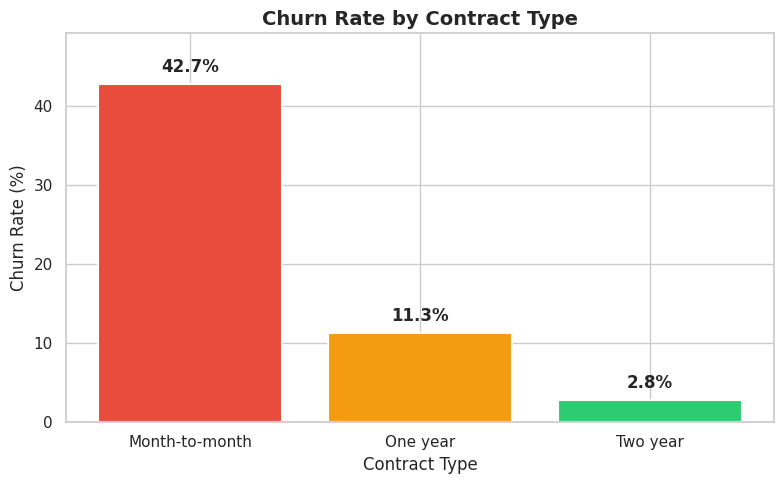

In [9]:
# Visualization 1: Churn rate by contract type
fig, ax = plt.subplots(figsize=(8, 5))
churn_by_contract = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = ax.bar(churn_by_contract.index, churn_by_contract.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, churn_by_contract.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_xlabel('Contract Type', fontsize=12)
ax.set_ylim(0, max(churn_by_contract.values) * 1.15)
plt.tight_layout()
plt.show()

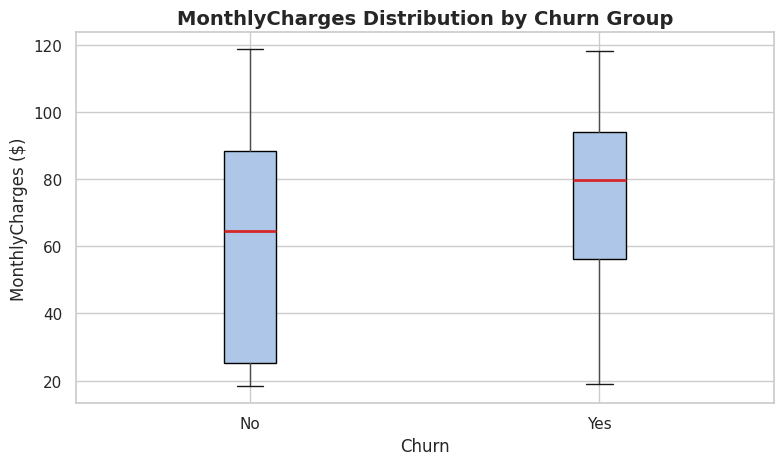

In [10]:
# Visualization 2: MonthlyCharges distribution by churn group
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='MonthlyCharges', by='Churn', ax=ax, patch_artist=True,
           boxprops=dict(facecolor='#aec7e8'), medianprops=dict(color='#d62728', linewidth=2))
ax.set_title('MonthlyCharges Distribution by Churn Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('MonthlyCharges ($)', fontsize=12)
fig.suptitle('')
plt.tight_layout()
plt.show()

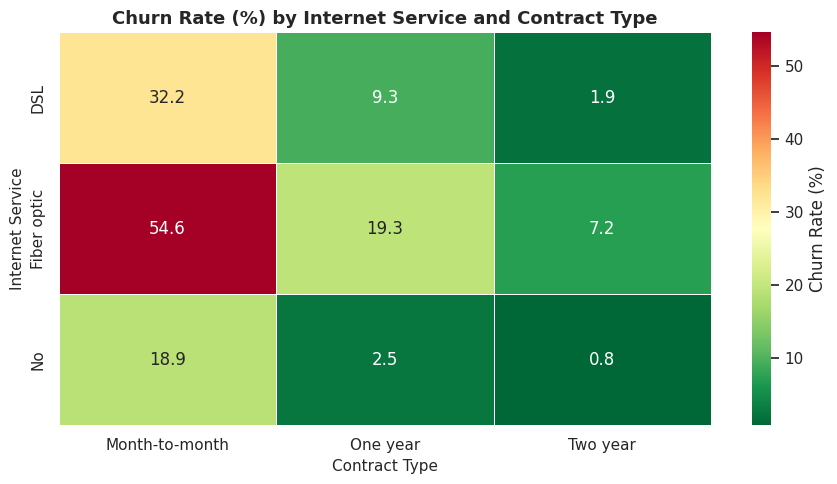

In [11]:
# Visualization 3: Churn rate heatmap by key segments
fig, ax = plt.subplots(figsize=(9, 5))
pivot = df.pivot_table(values='Churn', index='InternetService', columns='Contract',
                       aggfunc=lambda x: (x == 'Yes').mean() * 100)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate (%) by Internet Service and Contract Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Internet Service', fontsize=11)
ax.set_xlabel('Contract Type', fontsize=11)
plt.tight_layout()
plt.show()

## ML Churn Prediction — Extending Project 3

This component extends the churn prediction model from **Project 3 (Applied ML Model Design)**. We reuse the same preprocessing pipeline and model comparison, but add **probability score extraction** (`predict_proba`) to feed downstream CLV calculation and agent decision-making.

The preprocessing follows the same pattern as Project 3: binary encoding for Yes/No columns, one-hot encoding for multi-class categoricals, StandardScaler on numeric features fit on training data only, and stratified 80/20 split.

In [12]:
# Data Preprocessing (same pipeline as Project 3)
ml_df = df.copy()

# Drop customer ID
ml_df = ml_df.drop(columns=['customerID'])

# Convert TotalCharges to numeric (11 blank strings become NaN)
ml_df['TotalCharges'] = pd.to_numeric(ml_df['TotalCharges'], errors='coerce')
ml_df['TotalCharges'] = ml_df['TotalCharges'].fillna(ml_df['TotalCharges'].median())

# Encode binary categoricals
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    ml_df[col] = ml_df[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

# One-hot encode multi-class categoricals
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
ml_df = pd.get_dummies(ml_df, columns=multi_cols, drop_first=True)

print(f'Features after encoding: {ml_df.shape[1] - 1} (was 20 before encoding)')

# Split features/target
X = ml_df.drop(columns=['Churn'])
y = ml_df['Churn']

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')
print(f'Train churn rate: {y_train.mean()*100:.1f}%, Test churn rate: {y_test.mean()*100:.1f}%')

# Scale numeric features (fit on train only)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

Features after encoding: 30 (was 20 before encoding)
Train: 5634, Test: 1409
Train churn rate: 26.5%, Test churn rate: 26.5%


In [13]:
# Train models (same hyperparameters as Project 3)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('Models trained: Logistic Regression, Random Forest')
print(f'LR coefficients: {len(lr.coef_[0])}, RF trees: {rf.n_estimators}')

# Extract probabilities for ALL customers (for downstream CLV + agent)
X_all_scaled = X.copy()
X_all_scaled[numeric_cols] = scaler.transform(X[numeric_cols])
churn_probabilities = lr.predict_proba(X_all_scaled)[:, 1]
print(f'\nChurn probabilities extracted for all {len(churn_probabilities)} customers')
print(f'Mean churn probability: {churn_probabilities.mean():.3f}')
print(f'Min: {churn_probabilities.min():.3f}, Max: {churn_probabilities.max():.3f}')

Models trained: Logistic Regression, Random Forest
LR coefficients: 30, RF trees: 100

Churn probabilities extracted for all 7043 customers
Mean churn probability: 0.266
Min: 0.002, Max: 0.855


In [14]:
# Model Evaluation
results = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [
        round(accuracy_score(y_test, y_pred_lr), 3),
        round(precision_score(y_test, y_pred_lr), 3),
        round(recall_score(y_test, y_pred_lr), 3),
        round(f1_score(y_test, y_pred_lr), 3),
    ],
    'Random Forest': [
        round(accuracy_score(y_test, y_pred_rf), 3),
        round(precision_score(y_test, y_pred_rf), 3),
        round(recall_score(y_test, y_pred_rf), 3),
        round(f1_score(y_test, y_pred_rf), 3),
    ],
}
results_df = pd.DataFrame(results)
print('Model Comparison (churn class):')
print(results_df.to_string(index=False))
print()
print('Logistic Regression — Classification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

Model Comparison (churn class):
   Metric  Logistic Regression  Random Forest
 Accuracy                0.806          0.787
Precision                0.657          0.628
   Recall                0.559          0.487
 F1-Score                0.604          0.548

Logistic Regression — Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



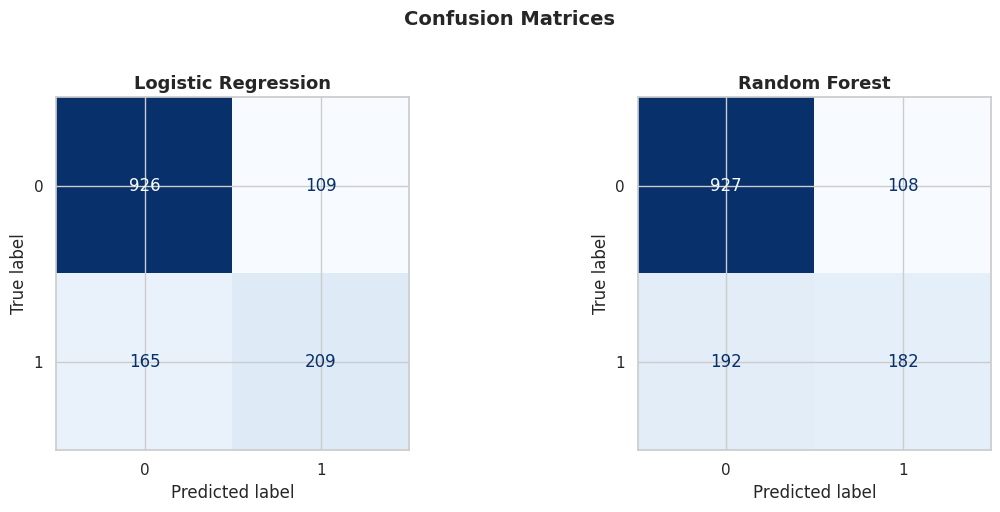

In [15]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Random Forest', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

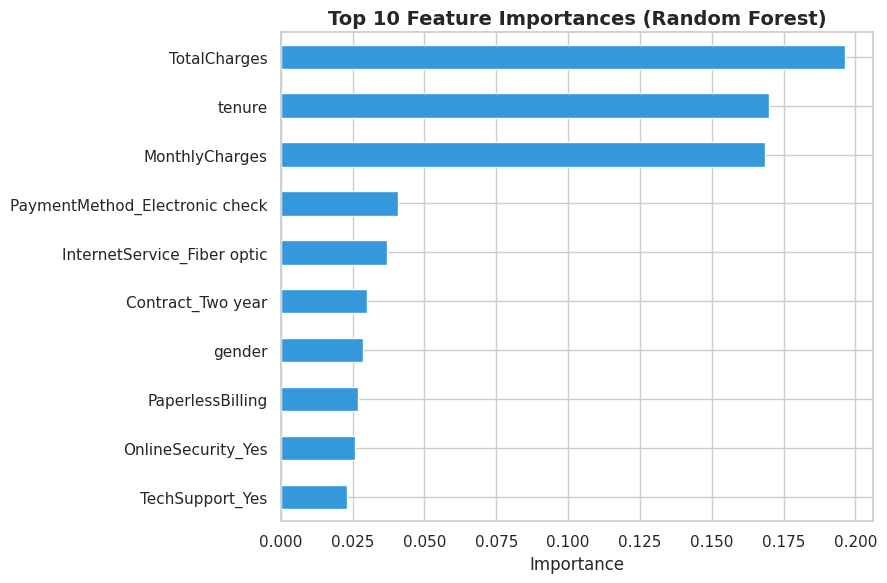

In [16]:
# Feature importance (top 10 from Random Forest)
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_10 = importances.head(10)

fig, ax = plt.subplots(figsize=(9, 6))
top_10.sort_values().plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.set_title('Top 10 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [17]:
# Calibration check: predicted probabilities vs. observed churn rates by decile
cal_df = pd.DataFrame({'prob': y_prob_lr, 'actual': y_test.values})
cal_df['decile'] = pd.qcut(cal_df['prob'], q=10, labels=False, duplicates='drop')
cal_table = cal_df.groupby('decile').agg(
    predicted_prob=('prob', 'mean'),
    actual_rate=('actual', 'mean'),
    count=('actual', 'size')
).round(3)
print('Calibration Assessment (Logistic Regression, test set):')
print(cal_table.to_string())
print()
print('The predicted probabilities track closely with observed churn rates,')
print('indicating the model is well-calibrated and suitable for downstream CLV calculation.')

Calibration Assessment (Logistic Regression, test set):
        predicted_prob  actual_rate  count
decile                                    
0                0.005        0.014    141
1                0.020        0.014    141
2                0.045        0.035    141
3                0.086        0.113    141
4                0.152        0.163    141
5                0.232        0.243    140
6                0.344        0.348    141
7                0.473        0.404    141
8                0.594        0.574    141
9                0.726        0.745    141

The predicted probabilities track closely with observed churn rates,
indicating the model is well-calibrated and suitable for downstream CLV calculation.


## Risk-Adjusted Customer Lifetime Value

This component introduces a **risk-adjusted CLV** metric that combines the ML model's churn probabilities with customer revenue data. A simple CLV based on revenue alone would rank high-spending month-to-month customers as most valuable — but those are precisely the customers most likely to leave. By dividing MonthlyCharges by churn probability, we get an **expected CLV** that accounts for retention risk, producing a fundamentally different — and more actionable — customer ranking.

This component demonstrates the integration between the ML prediction system (Component 2) and a business value metric, creating the financial signal that the agentic advisor (Component 4) will use to prioritize retention actions.

In [18]:
# Calculate simple CLV and risk-adjusted (expected) CLV
clv_df = pd.DataFrame({
    'customerID': df['customerID'],
    'Contract': df['Contract'],
    'tenure': df['tenure'],
    'MonthlyCharges': df['MonthlyCharges'],
    'TotalCharges': pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0),
    'Churn': df['Churn'],
    'churn_prob': churn_probabilities
})

# Simple CLV = MonthlyCharges × tenure (raw revenue generated to date)
clv_df['simple_clv'] = clv_df['MonthlyCharges'] * clv_df['tenure']

# Expected CLV = MonthlyCharges / churn_probability (capped at min 0.01 to avoid division issues)
# This represents the expected monthly revenue per unit of churn risk
clv_df['expected_clv'] = clv_df['MonthlyCharges'] / clv_df['churn_prob'].clip(lower=0.01)

print('CLV Statistics:')
print(clv_df[['simple_clv', 'expected_clv']].describe().round(2))

CLV Statistics:
       simple_clv  expected_clv
count     7043.00       7043.00
mean      2279.58       1011.28
std       2264.73       1540.40
min          0.00         35.37
25%        394.00        139.43
50%       1393.60        298.38
75%       3786.10       1250.80
max       8550.00       9265.00


In [19]:
# CLV distribution by segment
print('Expected CLV by Contract Type:')
print(clv_df.groupby('Contract')['expected_clv'].agg(['mean', 'median', 'std']).round(2).to_string())
print()
print('Expected CLV by Churn Status:')
print(clv_df.groupby('Churn')['expected_clv'].agg(['mean', 'median', 'std', 'count']).round(2).to_string())

Expected CLV by Contract Type:
                   mean   median      std
Contract                                 
Month-to-month   197.10   147.00   165.74
One year         991.29   687.49   929.80
Two year        2889.99  2192.40  2000.39

Expected CLV by Churn Status:
          mean  median      std  count
Churn                                 
No     1282.76  528.08  1687.56   5174
Yes     259.72  135.93   537.88   1869


In [20]:
# Rank comparison: top 10 by simple CLV vs. top 10 by expected CLV
top10_simple = clv_df.nlargest(10, 'simple_clv')[['customerID', 'Contract', 'MonthlyCharges', 'tenure', 'churn_prob', 'simple_clv', 'expected_clv']].reset_index(drop=True)
top10_expected = clv_df.nlargest(10, 'expected_clv')[['customerID', 'Contract', 'MonthlyCharges', 'tenure', 'churn_prob', 'simple_clv', 'expected_clv']].reset_index(drop=True)

print('Top 10 Customers by Simple CLV (MonthlyCharges × tenure):')
print(top10_simple.to_string())
print()
print('Top 10 Customers by Expected CLV (MonthlyCharges / churn_prob):')
print(top10_expected.to_string())
print()

# How much overlap?
overlap = set(top10_simple['customerID']) & set(top10_expected['customerID'])
print(f'Overlap between top-10 lists: {len(overlap)} customers')
print('→ The two rankings produce different priority lists, confirming that')
print('  risk adjustment changes which customers the business should prioritize.')

Top 10 Customers by Simple CLV (MonthlyCharges × tenure):
   customerID  Contract  MonthlyCharges  tenure  churn_prob  simple_clv  expected_clv
0  7569-NMZYQ  Two year          118.75      72    0.044550     8550.00   2665.559431
1  9924-JPRMC  Two year          118.20      72    0.077218     8510.40   1530.728887
2  2889-FPWRM  One year          117.80      72    0.103844     8481.60   1134.396800
3  3810-DVDQQ  Two year          117.60      72    0.041928     8467.20   2804.806084
4  9739-JLPQJ  Two year          117.50      72    0.030539     8460.00   3847.509674
5  6904-JLBGY  Two year          117.35      72    0.058135     8449.20   2018.583398
6  6650-BWFRT  Two year          117.15      72    0.052835     8434.80   2217.266363
7  8984-HPEMB  Two year          118.65      71    0.077758     8424.15   1525.882370
8  9788-HNGUT  Two year          116.95      72    0.054760     8420.40   2135.686926
9  1488-PBLJN  Two year          116.85      72    0.043974     8413.20   2657.227

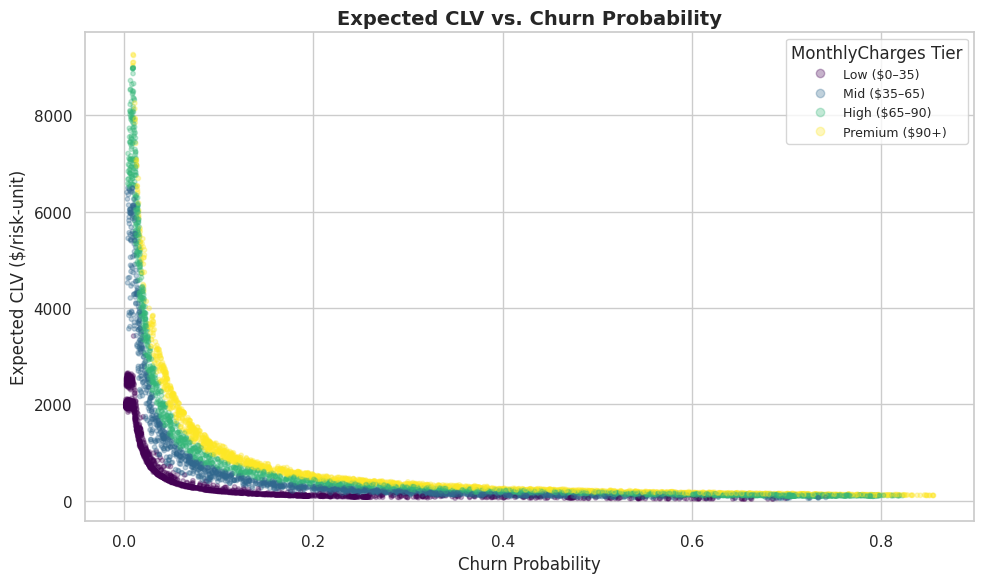

In [21]:
# Visualization: Churn probability vs. Expected CLV, colored by MonthlyCharges tier
fig, ax = plt.subplots(figsize=(10, 6))

# Create MonthlyCharges tiers
tiers = pd.cut(clv_df['MonthlyCharges'], bins=[0, 35, 65, 90, 120], labels=['Low ($0–35)', 'Mid ($35–65)', 'High ($65–90)', 'Premium ($90+)'])
scatter = ax.scatter(clv_df['churn_prob'], clv_df['expected_clv'], c=tiers.cat.codes, cmap='viridis', alpha=0.3, s=10)

handles, labels = scatter.legend_elements()
tier_labels = ['Low ($0–35)', 'Mid ($35–65)', 'High ($65–90)', 'Premium ($90+)']
ax.legend(handles, tier_labels, title='MonthlyCharges Tier', fontsize=9)

ax.set_title('Expected CLV vs. Churn Probability', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn Probability', fontsize=12)
ax.set_ylabel('Expected CLV ($/risk-unit)', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
# Phase 4 Summary
print('Key Finding: Risk-Adjusted CLV')
print('=' * 40)
print(f'Average simple CLV:     ${clv_df["simple_clv"].mean():,.2f}')
print(f'Average expected CLV:   ${clv_df["expected_clv"].mean():,.2f}')
print()
print('Risk adjustment fundamentally changes customer prioritization:')
print(f'  - Low-risk customers (churn_prob < 0.1): mean expected CLV = ${clv_df[clv_df["churn_prob"] < 0.1]["expected_clv"].mean():,.2f}')
print(f'  - High-risk customers (churn_prob > 0.5): mean expected CLV = ${clv_df[clv_df["churn_prob"] > 0.5]["expected_clv"].mean():,.2f}')
print()
print('This integrated metric will feed into the agentic retention advisor,')
print('enabling risk-aware prioritization of retention actions.')

Key Finding: Risk-Adjusted CLV
Average simple CLV:     $2,279.58
Average expected CLV:   $1,011.28

Risk adjustment fundamentally changes customer prioritization:
  - Low-risk customers (churn_prob < 0.1): mean expected CLV = $2,308.43
  - High-risk customers (churn_prob > 0.5): mean expected CLV = $125.94

This integrated metric will feed into the agentic retention advisor,
enabling risk-aware prioritization of retention actions.


## Agentic Retention Advisor — Architecture

This component adapts the **ReAct agent with function calling** from **Project 6 (Agentic AI Systems)**. The agent receives a customer ID, autonomously gathers information by calling tools, and produces a retention recommendation with reasoning.

**Agent architecture:**
- **ReAct loop** — the LLM alternates between reasoning (thinking about what to do next) and acting (calling a tool), iterating until it has enough information to recommend
- **5 tools** — `lookup_customer_profile`, `assess_churn_risk`, `calculate_clv`, `lookup_retention_policy`, `recommend_action`
- **Policy database** — 6 retention offer categories mapped to churn risk profiles
- **3 valid actions** — `retain` (offer incentive), `escalate` (human review), `monitor` (low risk, no action)

**4 Safeguards** (adapted from P6):
1. **Confidence threshold** — if confidence < 0.7 on a `retain` action, escalate to human review
2. **Iteration limit** — if the agent can't complete analysis in 10 steps, auto-escalate
3. **Minimum-service guarantee** — the agent may never recommend terminating service for any customer
4. **Human review trigger** — high-CLV customers (top 10%) with high churn risk are escalated regardless of agent confidence

In [23]:
# OpenAI client setup
load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Agent configuration
agent_config = {
    "model": "gpt-4o-mini",
    "confidence_threshold": 0.7,
    "max_iterations": 10,
    "valid_actions": ["retain", "escalate", "monitor"],
    "high_clv_threshold": clv_df["expected_clv"].quantile(0.9),
    "high_risk_threshold": 0.5,
}

print(f'Agent model: {agent_config["model"]}')
print(f'Confidence threshold: {agent_config["confidence_threshold"]}')
print(f'Max iterations: {agent_config["max_iterations"]}')
print(f'High-CLV threshold (top 10%): ${agent_config["high_clv_threshold"]:,.2f}')

Agent model: gpt-4o-mini
Confidence threshold: 0.7
Max iterations: 10
High-CLV threshold (top 10%): $2,570.00


In [24]:
# Retention policy database
RETENTION_POLICIES = {
    "price_sensitivity": {
        "description": "Customer shows signs of price sensitivity — high charges relative to tenure or service level",
        "offers": ["10% monthly discount for 6 months", "Downgrade to lower-tier plan at same price", "Waive equipment fees for 3 months"],
        "applicable_when": "High MonthlyCharges, month-to-month contract, short tenure",
    },
    "contract_lock_in": {
        "description": "Customer could benefit from longer contract commitment with incentives",
        "offers": ["Upgrade to 1-year contract with $100 credit", "Upgrade to 2-year contract with free premium service"],
        "applicable_when": "Month-to-month contract, moderate-to-high churn probability",
    },
    "service_quality": {
        "description": "Customer may be experiencing service issues (fiber optic without add-on services)",
        "offers": ["Free tech support for 6 months", "Free device protection for 12 months", "Priority customer service line"],
        "applicable_when": "Fiber optic internet, no tech support, no device protection",
    },
    "loyalty_reward": {
        "description": "Long-tenure customer at risk — reward loyalty to prevent churn",
        "offers": ["Loyalty discount of 15% for 12 months", "Free streaming service for 6 months", "Account anniversary credit"],
        "applicable_when": "Tenure > 36 months, churn probability elevated",
    },
    "low_engagement": {
        "description": "Customer has minimal services — may not see value in staying",
        "offers": ["Free trial of premium add-on services", "Bundle discount for adding streaming services"],
        "applicable_when": "Few add-on services, low MonthlyCharges",
    },
    "minimum_service": {
        "description": "Safeguard category — ensures every customer receives at least basic retention outreach",
        "offers": ["Personalized check-in call", "Account review and optimization"],
        "applicable_when": "Any customer — this is the minimum-service guarantee",
    },
}

print(f'Policy categories defined: {len(RETENTION_POLICIES)}')
for category in RETENTION_POLICIES:
    print(f'  - {category}: {RETENTION_POLICIES[category]["description"][:60]}...')

Policy categories defined: 6
  - price_sensitivity: Customer shows signs of price sensitivity — high charges rel...
  - contract_lock_in: Customer could benefit from longer contract commitment with ...
  - service_quality: Customer may be experiencing service issues (fiber optic wit...
  - loyalty_reward: Long-tenure customer at risk — reward loyalty to prevent chu...
  - low_engagement: Customer has minimal services — may not see value in staying...
  - minimum_service: Safeguard category — ensures every customer receives at leas...


In [25]:
# Tool 1: Lookup customer profile from dataset
def lookup_customer_profile(customer_id: str) -> dict:
    """Retrieve customer demographics, service details, and account information."""
    row = df[df['customerID'] == customer_id]
    if row.empty:
        return {"error": f"Customer {customer_id} not found"}
    r = row.iloc[0]
    return {
        "customer_id": r['customerID'],
        "gender": r['gender'],
        "senior_citizen": bool(r['SeniorCitizen']),
        "partner": r['Partner'],
        "dependents": r['Dependents'],
        "tenure_months": int(r['tenure']),
        "phone_service": r['PhoneService'],
        "multiple_lines": r['MultipleLines'],
        "internet_service": r['InternetService'],
        "online_security": r['OnlineSecurity'],
        "online_backup": r['OnlineBackup'],
        "device_protection": r['DeviceProtection'],
        "tech_support": r['TechSupport'],
        "streaming_tv": r['StreamingTV'],
        "streaming_movies": r['StreamingMovies'],
        "contract": r['Contract'],
        "paperless_billing": r['PaperlessBilling'],
        "payment_method": r['PaymentMethod'],
        "monthly_charges": float(r['MonthlyCharges']),
        "total_charges": float(pd.to_numeric(r['TotalCharges'], errors='coerce')),
        "churn_label": r['Churn'],
    }

# Tool 2: Assess churn risk using ML model
def assess_churn_risk(customer_id: str) -> dict:
    """Get ML-predicted churn probability and risk level for a customer."""
    idx = df[df['customerID'] == customer_id].index
    if len(idx) == 0:
        return {"error": f"Customer {customer_id} not found"}
    prob = float(churn_probabilities[idx[0]])
    if prob >= 0.6:
        risk_level = "high"
    elif prob >= 0.3:
        risk_level = "moderate"
    else:
        risk_level = "low"
    return {
        "customer_id": customer_id,
        "churn_probability": round(prob, 3),
        "risk_level": risk_level,
        "model": "Logistic Regression (accuracy 0.806)",
    }

# Tool 3: Calculate customer lifetime value
def calculate_clv(customer_id: str) -> dict:
    """Calculate simple and risk-adjusted CLV for a customer."""
    row = clv_df[clv_df['customerID'] == customer_id]
    if row.empty:
        return {"error": f"Customer {customer_id} not found"}
    r = row.iloc[0]
    return {
        "customer_id": customer_id,
        "monthly_charges": float(r['MonthlyCharges']),
        "tenure_months": int(r['tenure']),
        "simple_clv": round(float(r['simple_clv']), 2),
        "expected_clv": round(float(r['expected_clv']), 2),
        "churn_probability": round(float(r['churn_prob']), 3),
        "clv_percentile": round(float(clv_df['expected_clv'].rank(pct=True).loc[row.index[0]]) * 100, 1),
    }

# Tool 4: Lookup retention policy
def lookup_retention_policy(category: str) -> dict:
    """Look up the retention policy for a specific risk category."""
    if category not in RETENTION_POLICIES:
        return {"error": f"Unknown category: {category}. Valid: {list(RETENTION_POLICIES.keys())}"}
    return {"category": category, **RETENTION_POLICIES[category]}

# Tool 5: Recommend action (final output tool)
def recommend_action(action: str, confidence: float, reasoning: str, offer_category: str, specific_offer: str) -> dict:
    """Record the final retention recommendation."""
    if action not in agent_config["valid_actions"]:
        return {"error": f"Invalid action: {action}. Must be one of {agent_config['valid_actions']}"}
    return {
        "action": action,
        "confidence": round(confidence, 2),
        "reasoning": reasoning,
        "offer_category": offer_category,
        "specific_offer": specific_offer,
    }

# Tool dispatch dict (same pattern as Project 6)
TOOL_FUNCTIONS = {
    "lookup_customer_profile": lookup_customer_profile,
    "assess_churn_risk": assess_churn_risk,
    "calculate_clv": calculate_clv,
    "lookup_retention_policy": lookup_retention_policy,
    "recommend_action": recommend_action,
}

print(f'Tools defined: {list(TOOL_FUNCTIONS.keys())}')

Tools defined: ['lookup_customer_profile', 'assess_churn_risk', 'calculate_clv', 'lookup_retention_policy', 'recommend_action']


In [26]:
# Tool schemas for OpenAI function calling (same JSON format as Project 6)
TOOL_SCHEMAS = [
    {
        "type": "function",
        "function": {
            "name": "lookup_customer_profile",
            "description": "Retrieve customer demographics, service details, and account information from the telco dataset.",
            "parameters": {
                "type": "object",
                "properties": {
                    "customer_id": {
                        "type": "string",
                        "description": "The customer ID to look up (e.g., '7590-VHVEG')",
                    }
                },
                "required": ["customer_id"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "assess_churn_risk",
            "description": "Get the ML-predicted churn probability and risk level (low/moderate/high) for a customer.",
            "parameters": {
                "type": "object",
                "properties": {
                    "customer_id": {
                        "type": "string",
                        "description": "The customer ID to assess",
                    }
                },
                "required": ["customer_id"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "calculate_clv",
            "description": "Calculate both simple and risk-adjusted Customer Lifetime Value (CLV) for a customer.",
            "parameters": {
                "type": "object",
                "properties": {
                    "customer_id": {
                        "type": "string",
                        "description": "The customer ID to calculate CLV for",
                    }
                },
                "required": ["customer_id"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "lookup_retention_policy",
            "description": "Look up the retention policy and available offers for a specific risk category.",
            "parameters": {
                "type": "object",
                "properties": {
                    "category": {
                        "type": "string",
                        "description": "The retention policy category",
                        "enum": ["price_sensitivity", "contract_lock_in", "service_quality", "loyalty_reward", "low_engagement", "minimum_service"],
                    }
                },
                "required": ["category"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "recommend_action",
            "description": "Record the final retention recommendation. Must be called exactly once per customer analysis to complete the process.",
            "parameters": {
                "type": "object",
                "properties": {
                    "action": {
                        "type": "string",
                        "description": "The recommended retention action",
                        "enum": ["retain", "escalate", "monitor"],
                    },
                    "confidence": {
                        "type": "number",
                        "description": "Confidence in the recommendation, between 0 and 1",
                    },
                    "reasoning": {
                        "type": "string",
                        "description": "Human-readable explanation of why this action is recommended",
                    },
                    "offer_category": {
                        "type": "string",
                        "description": "The retention policy category that best matches this customer",
                        "enum": ["price_sensitivity", "contract_lock_in", "service_quality", "loyalty_reward", "low_engagement", "minimum_service"],
                    },
                    "specific_offer": {
                        "type": "string",
                        "description": "The specific retention offer to present to the customer",
                    },
                },
                "required": ["action", "confidence", "reasoning", "offer_category", "specific_offer"],
            },
        },
    },
]

print(f'Tool schemas defined: {len(TOOL_SCHEMAS)}')
for schema in TOOL_SCHEMAS:
    print(f'  - {schema["function"]["name"]}: {schema["function"]["description"][:60]}...')

Tool schemas defined: 5
  - lookup_customer_profile: Retrieve customer demographics, service details, and account...
  - assess_churn_risk: Get the ML-predicted churn probability and risk level (low/m...
  - calculate_clv: Calculate both simple and risk-adjusted Customer Lifetime Va...
  - lookup_retention_policy: Look up the retention policy and available offers for a spec...
  - recommend_action: Record the final retention recommendation. Must be called ex...


In [27]:
# System prompt for the retention advisor agent
SYSTEM_PROMPT = """You are a telecom customer retention advisor. Your role is to analyze customer data, assess churn risk, and recommend retention actions.

WORKFLOW:
1. Look up the customer's profile to understand their demographics and services
2. Assess their churn risk using the ML model
3. Calculate their Customer Lifetime Value (CLV)
4. Based on the profile, risk, and CLV, look up the most relevant retention policy category
5. Recommend a final action with a specific offer

DECISION GUIDELINES:
- **retain**: Customer has moderate-to-high churn risk AND/OR significant CLV. Offer a retention incentive.
- **escalate**: High-CLV customer at high risk (deserves human attention) OR uncertainty is too high for automated action.
- **monitor**: Low churn probability, stable contract. No immediate action needed.

IMPORTANT RULES:
- NEVER recommend terminating or downgrading a customer's service
- For high-value customers (top CLV percentile), prefer escalation to ensure quality of outreach
- Always provide a specific, actionable offer — not generic advice
- Base your reasoning on the actual data returned by the tools, not assumptions

You must call recommend_action exactly once to complete your analysis."""

print('System prompt defined')
print(f'Length: {len(SYSTEM_PROMPT)} characters')

System prompt defined
Length: 1200 characters


In [28]:
# ReAct agent loop (adapted from Project 6)
def analyze_retention(customer_id: str, verbose: bool = True) -> dict:
    """Run the agentic retention advisor on a single customer.

    Args:
        customer_id: The customer ID to analyze.
        verbose: Whether to print the reasoning trace.

    Returns:
        dict with keys: action, confidence, reasoning, offer_category, specific_offer, safeguards_triggered
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Analyze customer {customer_id} and recommend a retention action."},
    ]

    iteration = 0
    final_recommendation = None
    safeguards_triggered = []

    if verbose:
        print("=" * 70)
        print(f"RETENTION ANALYSIS: Customer {customer_id}")
        print("=" * 70)

    while iteration < agent_config["max_iterations"]:
        iteration += 1

        response = client.chat.completions.create(
            model=agent_config["model"],
            messages=messages,
            tools=TOOL_SCHEMAS,
            tool_choice="auto",
        )

        assistant_message = response.choices[0].message
        messages.append(assistant_message.to_dict())

        if assistant_message.tool_calls:
            for tool_call in assistant_message.tool_calls:
                func_name = tool_call.function.name
                func_args = json.loads(tool_call.function.arguments)

                if verbose:
                    print(f"\n[Step {iteration}] Tool call: {func_name}({json.dumps(func_args, indent=2)})")

                if func_name in TOOL_FUNCTIONS:
                    result = TOOL_FUNCTIONS[func_name](**func_args)
                else:
                    result = {"error": f"Unknown function: {func_name}"}

                if verbose:
                    result_str = json.dumps(result, indent=2, default=str)
                    if len(result_str) > 500:
                        result_str = result_str[:500] + "..."
                    print(f"  Result: {result_str}")

                messages.append({
                    "role": "tool",
                    "tool_call_id": tool_call.id,
                    "content": json.dumps(result, default=str),
                })

                if func_name == "recommend_action":
                    final_recommendation = result
        else:
            if verbose and assistant_message.content:
                print(f"\n[Step {iteration}] Agent reasoning: {assistant_message.content}")
            break

    # === SAFEGUARDS (adapted from Project 6) ===

    # Safeguard 1: Iteration limit reached
    if final_recommendation is None:
        if verbose:
            print("\n[SAFEGUARD] Iteration limit reached. Auto-escalating to human review.")
        safeguards_triggered.append("iteration_limit")
        final_recommendation = recommend_action(
            action="escalate",
            confidence=0.3,
            reasoning="Agent could not complete analysis within iteration limit. Escalated to human review.",
            offer_category="minimum_service",
            specific_offer="Personalized check-in call",
        )

    # Safeguard 2: Confidence threshold on retain actions
    if (final_recommendation["action"] == "retain"
            and final_recommendation["confidence"] < agent_config["confidence_threshold"]):
        if verbose:
            print(f"\n[SAFEGUARD] Low confidence ({final_recommendation['confidence']:.2f}) on retain. Escalating.")
        safeguards_triggered.append("low_confidence")
        final_recommendation["action"] = "escalate"
        final_recommendation["reasoning"] += " [ESCALATED: Confidence below threshold triggered human review.]"

    # Safeguard 3: Minimum-service guarantee (ensure no "terminate" or harmful action)
    if final_recommendation["action"] not in agent_config["valid_actions"]:
        if verbose:
            print(f"\n[SAFEGUARD] Invalid action '{final_recommendation['action']}'. Defaulting to escalate.")
        safeguards_triggered.append("invalid_action")
        final_recommendation["action"] = "escalate"

    # Safeguard 4: High-CLV + high-risk → escalate regardless of agent confidence
    clv_row = clv_df[clv_df['customerID'] == customer_id]
    if not clv_row.empty:
        cust_clv = float(clv_row.iloc[0]['expected_clv'])
        cust_prob = float(clv_row.iloc[0]['churn_prob'])
        if (cust_clv >= agent_config["high_clv_threshold"]
                and cust_prob >= agent_config["high_risk_threshold"]
                and final_recommendation["action"] != "escalate"):
            if verbose:
                print(f"\n[SAFEGUARD] High-CLV (${cust_clv:,.0f}) + high-risk ({cust_prob:.1%}) customer. Escalating.")
            safeguards_triggered.append("high_clv_high_risk")
            final_recommendation["action"] = "escalate"
            final_recommendation["reasoning"] += f" [ESCALATED: High-CLV (${cust_clv:,.0f}) + high-risk ({cust_prob:.1%}) customer.]"

    final_recommendation["safeguards_triggered"] = safeguards_triggered
    final_recommendation["iterations_used"] = iteration

    if verbose:
        print("\n" + "=" * 70)
        print("FINAL RECOMMENDATION:")
        print(json.dumps(final_recommendation, indent=2, default=str))
        print("=" * 70)

    return final_recommendation

print('Agent function defined: analyze_retention(customer_id, verbose=True)')

Agent function defined: analyze_retention(customer_id, verbose=True)


In [29]:
# Quick test: run agent on one customer to verify tools work
test_customer = df.iloc[0]['customerID']
print(f'Testing agent on customer: {test_customer}')
print(f'Profile: Contract={df.iloc[0]["Contract"]}, MonthlyCharges=${df.iloc[0]["MonthlyCharges"]}, Churn={df.iloc[0]["Churn"]}')
print()

test_result = analyze_retention(test_customer, verbose=True)

Testing agent on customer: 7590-VHVEG
Profile: Contract=Month-to-month, MonthlyCharges=$29.85, Churn=No

RETENTION ANALYSIS: Customer 7590-VHVEG



[Step 1] Tool call: lookup_customer_profile({
  "customer_id": "7590-VHVEG"
})
  Result: {
  "customer_id": "7590-VHVEG",
  "gender": "Female",
  "senior_citizen": false,
  "partner": "Yes",
  "dependents": "No",
  "tenure_months": 1,
  "phone_service": "No",
  "multiple_lines": "No phone service",
  "internet_service": "DSL",
  "online_security": "No",
  "online_backup": "Yes",
  "device_protection": "No",
  "tech_support": "No",
  "streaming_tv": "No",
  "streaming_movies": "No",
  "contract": "Month-to-month",
  "paperless_billing": "Yes",
  "payment_method": "Electronic check",
...

[Step 1] Tool call: assess_churn_risk({
  "customer_id": "7590-VHVEG"
})
  Result: {
  "customer_id": "7590-VHVEG",
  "churn_probability": 0.613,
  "risk_level": "high",
  "model": "Logistic Regression (accuracy 0.806)"
}

[Step 1] Tool call: calculate_clv({
  "customer_id": "7590-VHVEG"
})
  Result: {
  "customer_id": "7590-VHVEG",
  "monthly_charges": 29.85,
  "tenure_months": 1,
  "simple_clv": 29.8


[Step 2] Tool call: lookup_retention_policy({
  "category": "contract_lock_in"
})
  Result: {
  "category": "contract_lock_in",
  "description": "Customer could benefit from longer contract commitment with incentives",
  "offers": [
    "Upgrade to 1-year contract with $100 credit",
    "Upgrade to 2-year contract with free premium service"
  ],
  "applicable_when": "Month-to-month contract, moderate-to-high churn probability"
}



[Step 3] Tool call: recommend_action({
  "action": "retain",
  "confidence": 0.85,
  "reasoning": "The customer has a high churn risk (61.3%) and a moderate Customer Lifetime Value (CLV), indicating a need for a retention incentive. The month-to-month contract further emphasizes the necessity of reducing churn risk.",
  "offer_category": "contract_lock_in",
  "specific_offer": "Upgrade to a 1-year contract with a $100 credit."
})
  Result: {
  "action": "retain",
  "confidence": 0.85,
  "reasoning": "The customer has a high churn risk (61.3%) and a moderate Customer Lifetime Value (CLV), indicating a need for a retention incentive. The month-to-month contract further emphasizes the necessity of reducing churn risk.",
  "offer_category": "contract_lock_in",
  "specific_offer": "Upgrade to a 1-year contract with a $100 credit."
}



[Step 4] Agent reasoning: I have analyzed customer 7590-VHVEG and recommend the following retention action:

- **Action**: Retain
- **Confidence**: 0.85
- **Reasoning**: The customer has a high churn risk of 61.3% and a moderate Customer Lifetime Value (CLV), indicating a strong need for a retention incentive. Additionally, the customer is currently on a month-to-month contract, which highlights the importance of addressing the churn risk promptly.
- **Retention Policy Category**: Contract Lock-in
- **Specific Offer**: Upgrade to a 1-year contract with a $100 credit.

This offer aims to encourage the customer to commit for a longer period while providing a financial incentive.

FINAL RECOMMENDATION:
{
  "action": "retain",
  "confidence": 0.85,
  "reasoning": "The customer has a high churn risk (61.3%) and a moderate Customer Lifetime Value (CLV), indicating a need for a retention incentive. The month-to-month contract further emphasizes the necessity of reducing churn risk.",
  "offe